In [1]:
!pip install sec-api
!pip install WordCloud
!pip install STOPWORDS
!pip install ImageColorGenerator

ERROR: Could not find a version that satisfies the requirement ImageColorGenerator (from versions: none)
ERROR: No matching distribution found for ImageColorGenerator


In [2]:
from sec_api import ExtractorApi # https://pypi.org/project/sec-api/
# get API from sec-api.io
extractorApi = ExtractorApi("22231cbaef2a634ccfdbe394d64a0bd37c9f642bea363b3df4c2f9e61580441c")


# Apple 10-K filing
filing_url = "https://www.sec.gov/Archives/edgar/data/320193/000032019323000106/aapl-20230930.htm"

# get the standardized and cleaned text of section 1A "Risk Factors"
section_text = extractorApi.get_section(filing_url, "1A", "text")

# get the original HTML of section 7 
# "Management’s Discussion and Analysis of Financial Condition and Results of Operations"
section_html = extractorApi.get_section(filing_url, "7", "html")
print (section_text)

 Item 1A. Risk Factors 

The Company&#8217;s business, reputation, results of operations, financial condition and stock price can be affected by a number of factors, whether currently known or unknown, including those described below. When any one or more of these risks materialize from time to time, the Company&#8217;s business, reputation, results of operations, financial condition and stock price can be materially and adversely affected. 

Because of the following factors, as well as other factors affecting the Company&#8217;s results of operations and financial condition, past financial performance should not be considered to be a reliable indicator of future performance, and investors should not use historical trends to anticipate results or trends in future periods. This discussion of risk factors contains forward-looking statements. 

This section should be read in conjunction with Part II, Item 7, &#8220;Management&#8217;s Discussion and Analysis of Financial Condition and Resu

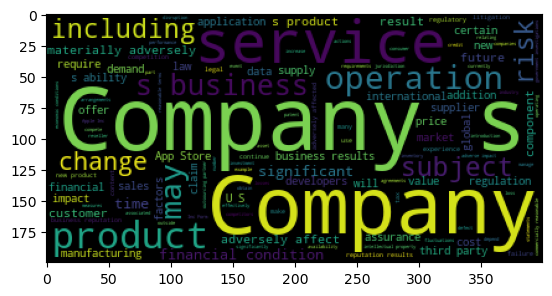

In [3]:
import pandas as pd
import numpy as np

#for plotting images & adjusting colors
import matplotlib.pyplot as plt
import matplotlib as mpl
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image

wc = WordCloud().generate(section_text)
plt.imshow(wc)

In [4]:
# import libraries
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# if you don't have vadar_lexicon data, you can run the following command in a terminal window:
#python -m nltk.downloader vader_lexicon

# download nltk corpus (first time only)
#nltk.download('all')

In [5]:
#Create a Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()
#Analyze section_text
scores = analyzer.polarity_scores(section_text)

print(scores)
#the compound key is a normalized score that ranges from -1(most negative) to 1(most positive)

{'neg': 0.094, 'neu': 0.818, 'pos': 0.087, 'compound': -0.9938}


In [6]:
#We can also check which score is the highest and use that to classify the text as positive, negative, or neutral.
if scores['compound'] >= 0.5:
    print("Positive")
elif scores['compound'] >-0.5:
    print("Neutral")
else:
    print("Negative")

Negative
